# Training Results Visualization

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

## Load Results

In [42]:
def load_results(result_path):
    with open(result_path, 'r') as f:
        data = json.load(f)

    steps = [item['step'] for item in data]
    val_perplexity = [item['val_perplexity'] for item in data]
    eval_perplexity = [item['eval_perplexity'] for item in data]

    return {
        'steps': np.array(steps),
        'val_perplexity': np.array(val_perplexity),
        'eval_perplexity': np.array(eval_perplexity),
    }

dataset_percentage='0.1'
batch_size=8
n_val=5
model='llama3-1b'
topic='tydiqa' # sociology, abstract_algebra, machine_learning, or tydiqa
lr='5e-05'
seed='3'

setting=f'{model}-lora-{topic}-p{dataset_percentage}-lr{lr}-b{batch_size}-n_val{n_val}-s{seed}'
# Example: Load results from different experiments
experiments = {
    'Regular': f'./out/Regular-Vanilla-{setting}/evaluation_results.json',
    'GREATS (LoGra)': f'./out/GREATS-LoGra-{setting}/evaluation_results.json',
    'GREATS (GraSS)': f'./out/GREATS-GraSS-{setting}/evaluation_results.json',
}

# Load all results
results = {}
for name, path in experiments.items():
    if Path(path).exists():
        results[name] = load_results(path)
        print(f"Loaded {name}: {len(results[name]['steps'])} evaluation points")
    else:
        print(f"Warning: {path} not found")

Loaded Regular: 2 evaluation points
Loaded GREATS (LoGra): 33 evaluation points
Loaded GREATS (GraSS): 33 evaluation points


## Plot Perplexity Over Training

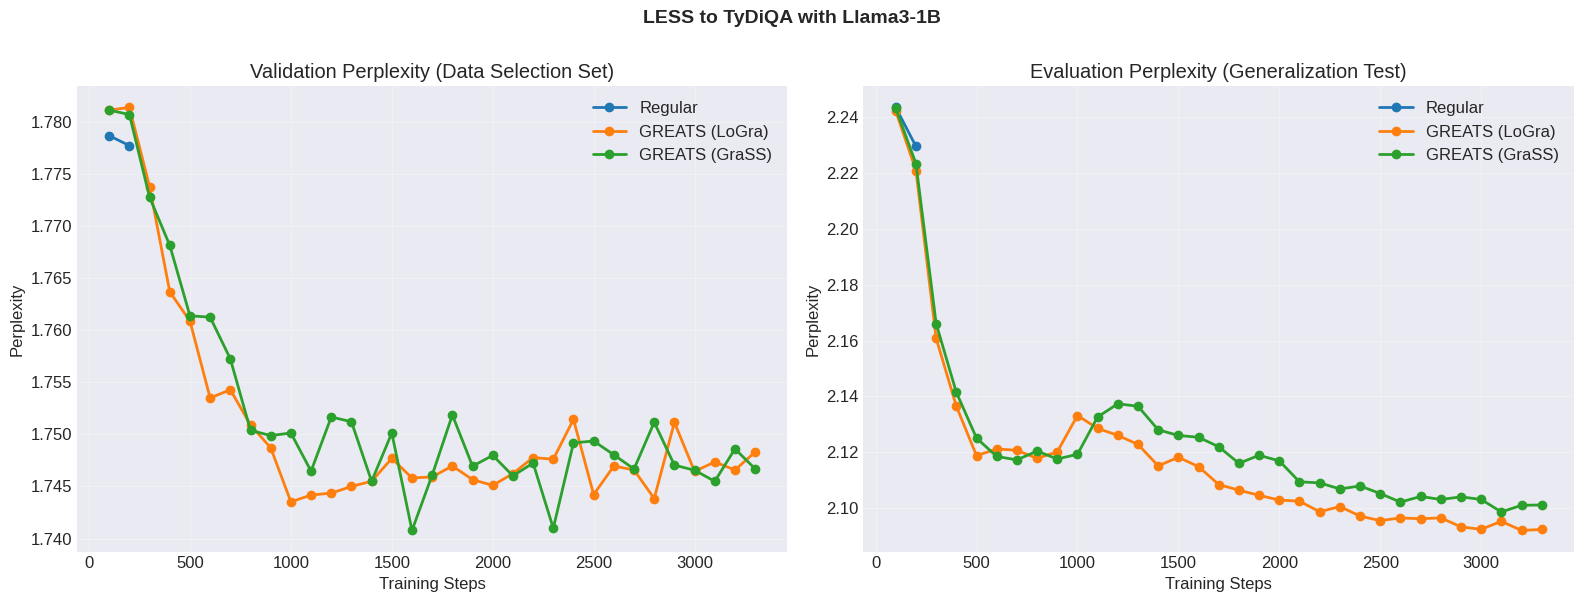

In [43]:
# Plotting configuration
max_steps = None  # Change to e.g., 100 to plot only first 100 steps
step_interval = None  # Change to e.g., 5 to plot every 5th step

if topic == 'tydiqa':
    plot_title = f"LESS to TyDiQA with {model.replace('_', ' ').title()}"
else:
    plot_title = f"LESS to MMLU ({topic.replace('_', ' ').title()}) with {model.replace('_', ' ').title()}"

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Add main title
fig.suptitle(plot_title, fontsize=14, fontweight='bold', y=1.00)

# Plot validation perplexity (small set for data selection)
ax = axes[0]
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        val_perp = data['val_perplexity'][mask]
    else:
        steps = data['steps']
        val_perp = data['val_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        val_perp = val_perp[indices]

    ax.plot(steps, val_perp, label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Validation Perplexity (Data Selection Set)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot evaluation perplexity (large held-out set)
ax = axes[1]
for name, data in results.items():
    # Filter data by max_steps if specified
    if max_steps is not None:
        mask = data['steps'] <= max_steps
        steps = data['steps'][mask]
        eval_perp = data['eval_perplexity'][mask]
    else:
        steps = data['steps']
        eval_perp = data['eval_perplexity']

    # Sample every N-th step if step_interval is specified
    if step_interval is not None:
        indices = np.arange(0, len(steps), step_interval)
        steps = steps[indices]
        eval_perp = eval_perp[indices]

    ax.plot(steps, eval_perp, label=name, marker='o', linewidth=2)
ax.set_xlabel('Training Steps')
ax.set_ylabel('Perplexity')
ax.set_title('Evaluation Perplexity (Generalization Test)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Compare Final Performance

In [4]:
# Print final results
print("\n=== Final Perplexity Results ===")
print(f"{'Method':<15} {'Val Perplexity':<20} {'Eval Perplexity':<20}")
print("-" * 55)

for name, data in results.items():
    final_val = data['val_perplexity'][-1]
    final_eval = data['eval_perplexity'][-1]
    print(f"{name:<15} {final_val:<20.4f} {final_eval:<20.4f}")


=== Final Perplexity Results ===
Method          Val Perplexity       Eval Perplexity     
-------------------------------------------------------
GREATS (LoGra)  1.7444               2.1260              
GREATS (GraSS)  1.7517               2.1373              


## Plot Improvement Over Baseline

In [5]:
# If you have a baseline (e.g., 'Regular'), compute relative improvement
if 'Regular' in results and len(results) > 1:
    baseline = results['Regular']

    plt.figure(figsize=(10, 6))

    for name, data in results.items():
        if name == 'Regular':
            continue

        # Filter data by max_steps if specified
        if max_steps is not None:
            mask = data['steps'] <= max_steps
            steps = data['steps'][mask]
            data_eval_perp = data['eval_perplexity'][mask]

            # Also filter baseline to match the steps
            baseline_mask = baseline['steps'] <= max_steps
            baseline_eval_perp = baseline['eval_perplexity'][baseline_mask]

            # Align baseline with current data's steps
            # Find baseline values at the same steps as current data
            baseline_interp = np.interp(steps, baseline['steps'][baseline_mask], baseline_eval_perp)
        else:
            steps = data['steps']
            data_eval_perp = data['eval_perplexity']
            baseline_interp = np.interp(steps, baseline['steps'], baseline['eval_perplexity'])

        # Compute percentage improvement on evaluation set
        # Lower perplexity is better, so improvement = (baseline - current) / baseline * 100
        improvement = (baseline_interp - data_eval_perp) / baseline_interp * 100

        # Sample every N-th step if step_interval is specified
        if step_interval is not None:
            indices = np.arange(0, len(steps), step_interval)
            steps = steps[indices]
            improvement = improvement[indices]

        plt.plot(steps, improvement, label=name, marker='o', linewidth=2)

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Baseline (Regular)')
    plt.xlabel('Training Steps')
    plt.ylabel('Improvement over Baseline (%)')

    # Add main title to improvement plot as well
    improvement_title = f"Topic: {topic.replace('_', ' ').title()} | Model: {model}"
    plt.title(f'{improvement_title}\nEvaluation Perplexity Improvement vs Regular Training')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Load MMLU Accuracy Results (if available)

In [6]:
# Load MMLU results if available
mmlu_experiments = {
    'Regular': './out/REGULAR-llama3-1b-p-lora-seed3/mmlu_results.json',
    'GREATS': './out/GREATS-llama3-1b-p-lora-seed3/mmlu_results.json',
}

mmlu_results = {}
for name, path in mmlu_experiments.items():
    if Path(path).exists():
        with open(path, 'r') as f:
            mmlu_results[name] = json.load(f)
        print(f"Loaded MMLU results for {name}")

if mmlu_results:
    print("\n=== MMLU Accuracy Results ===")
    print(f"{'Method':<15} {'Subject':<15} {'Accuracy':<15} {'Correct/Total'}")
    print("-" * 60)

    for name, data in mmlu_results.items():
        accuracy = data['accuracy']
        subject = data.get('subject', 'N/A')
        correct = data.get('num_correct', 'N/A')
        total = data.get('num_total', 'N/A')
        print(f"{name:<15} {subject:<15} {accuracy:<15.4f} {correct}/{total}")

    # Bar chart of accuracies
    plt.figure(figsize=(10, 6))
    names = list(mmlu_results.keys())
    accuracies = [mmlu_results[name]['accuracy'] for name in names]

    plt.bar(names, accuracies, alpha=0.7, edgecolor='black')
    plt.ylabel('Accuracy')
    plt.title('MMLU Accuracy Comparison')
    plt.ylim([0, 1])
    plt.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for i, (name, acc) in enumerate(zip(names, accuracies)):
        plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('./mmlu_accuracy_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Plot saved to ./mmlu_accuracy_comparison.png")
else:
    print("\nNo MMLU results found. Run evaluate_mmlu.py to generate them.")


No MMLU results found. Run evaluate_mmlu.py to generate them.
